## 1 - Data Analysis & Extraction

El objetivo principal es extraer y analizar los datos de la base de datos ***MIMIC-IV***
El primer paso es analizar de que tipo de datos disponemos, de primeras se puede observar que el formato de los archivos es `csv.gz`, el formato `gz` indica que es un archivo comprimido, y previamente tiene el formato `csv`, por lo tanto se puede llegar a suponer que es un archivo csv comprimido. La librería pandas ayudará a leer los archivos csv comprimidos directamente sin descompresión manual.

Lo principal es importar las librerías que serán necesarias para analizar y procesar estos datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

In [ ]:
# Configuracion global
BASE_DATA_DIR = '../data'            # Directorio raíz del dataset MIMIC-IV
OUTPUT_DIR = '../data/processed'  # Directorio de salida para artefactos

HOURS_BEFORE = 48 # Ventana temporal previa al ingreso UCI (horas)
MIN_STAY_HOURS = 6 # Cobertura mínima de horas por estancia
N_CONTROLS = 29_966  # Controles no-sepsis (ratio 1:1 con sepsis)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

Con las librerías requeridas cargadas ya se pueden importar y empezar a usar los datos, aunque antes hay que entender cómo están estructurados y qué relación hay entre diferentes archivos `csv`.

Según la documentación de **MIMIC-IV** tenemos dos directorios principales:

- **hosp**: Contiene **546,028** registros únicos de hospitalizaciones para **223,452** individuos únicos. Estos datos se dividen en cuatro categorías principales:
    - **Información Básica y Logística**: Incluye los datos personales de los pacientes (edad, género, etc), y registra cuando entra y sale un paciente de una unidad en concreto.
    - **Datos Clínicos y de Laboratorio**: Contiene eventos registrados en un laboratorio, como por ejemplo resultados de análisis de sangre, orina, etc.
    - **Medicamentos**: Contiene las recetas prescritas por los médicos, también incluye un registro de cuando y como se ha administrado el medicamiento.
    - **Facturación y Diagnósticos**: Incluye los datos que indican los códigos de los diagnósticos y procedimientos realizados.

- **icu**: Contiene **94,458** registros de estancias de pacientes en la UCI. Estos datos se estructuran de forma que hay una tabla "estancias" central que se conecta con otras tablas de eventos, estas tablas registran todos los sucesos de un paciente minuto a minuto.

Con este conocimiento solo queda conocer los campos que enlazan las diferentes tablas, los campos más importantes son:

- `subject_id`: Identificador único del paciente
- `hadm_id`: Identificador único de admisión hospitalaria (un paciente puede tener más de una admisión)
- `stay_id`: Identificador único de estancia en la UCI (una admisión puede tener varias estancias)

In [3]:
ID_SUBJECT = 'subject_id'
ID_ADMISION = 'hadm_id'
ID_STAY = 'stay_id'

El primer paso se tratará de analizar los diagnósticos del dataset usando la variable `icd_code`, esta variable nos indica el código ICD del diagnóstico, este código usa un sistema estandarizado para codificar enfermedades, signos o síntomas, actualmente existen dos principales revisiones: **ICD-9** y **ICD-10**. Estas dos revisiones varían sobre todo en la cantidad de códigos y estructura, el objetivo es usar estos códigos para identificar en el dataset los diagnosis que contengan casos de sepsis, o algún síntoma o enfermedad que nos ayude a indicar la sepsis, se usará la variable `icd_version` para identificar la versión en los datos.


### ICD-9

| Código(s) | Descripción |
|-----------|-------------|
| **995.91** | Sepsis (SIRS de origen infeccioso) |
| **995.92** | Sepsis grave |
| **785.52** | Choque séptico |
| **038.0–038.9** | Septicemia (038.11 Staph aureus, 038.42 E. coli, 038.9 no especificada) |
| **771.81** | Sepsis neonatal |

### ICD-10

| Código(s) | Descripción |
|-----------|-------------|
| **A41.9** | Sepsis, organismo no especificado (el más común en registros) |
| **A40.0, A40.1, A40.3, A40.8, A40.9** | Sepsis por diferentes grupos de Estreptococos |
| **A41.01** | Sepsis por *Staphylococcus aureus* sensible a meticilina (MSSA) |
| **A41.02** | Sepsis por *Staphylococcus aureus* resistente a meticilina (MRSA) |
| **A41.51** | Sepsis por *Escherichia coli* |
| **A41.52** | Sepsis por *Pseudomonas* |
| **A41.81** | Sepsis por *Enterococcus* |
| **A41.89** | Sepsis por otros organismos especificados (incluye sepsis viral) |
| **A02.1** | Sepsis por *Salmonella* |
| **B37.7** | Sepsis candidiásica (fúngica) |
| **R65.20** | Sepsis grave sin choque séptico |
| **R65.21** | Sepsis grave con choque séptico |
| **P36.0–P36.9** | Sepsis bacteriana neonatal |
| **O85** | Sepsis puerperal (postparto) |
| **O75.3** | Sepsis durante el trabajo de parto |
| **T81.44** | Sepsis tras procedimiento quirúrgico |

In [4]:
diagnoses = pd.read_csv(f'{BASE_DATA_DIR}/hosp/diagnoses_icd.csv.gz')
print(diagnoses.shape)
print(diagnoses.dtypes)
print(diagnoses.head())

(6364488, 5)
subject_id     int64
hadm_id        int64
seq_num        int64
icd_code         str
icd_version    int64
dtype: object
   subject_id   hadm_id  seq_num icd_code  icd_version
0    10000032  22595853        1     5723            9
1    10000032  22595853        2    78959            9
2    10000032  22595853        3     5715            9
3    10000032  22595853        4    07070            9
4    10000032  22595853        5      496            9


In [5]:
ICD_CODE = 'icd_code' # Identificador del codigo de ICD 
ICD_VERSION = 'icd_version' # Identificador de la version de ICD

# ---------------------------------- ICD 9 ----------------------------------

# Definimos los codigos especificos de ICD9
SEPSIS_ICD9_EXPLICIT = {
    '99591',  # Sepsis
    '99592',  # Sepsis grave
    '78552',  # Choque séptico
    '77181',  # Sepsis neonatal
}

# Filtramos por version
icd9_df = diagnoses[diagnoses[ICD_VERSION] == 9].copy()

# Incluimos los diagnosis con codigo que empieza por 038 (Septicemia)
icd9_mask = (
    icd9_df[ICD_CODE].isin(SEPSIS_ICD9_EXPLICIT) |
    icd9_df[ICD_CODE].str.startswith('038')
)

# Evitamos registros duplicados identificandolos por admision
sepsis_icd9_hadm = icd9_df[icd9_mask][ID_ADMISION].unique()

# ---------------------------------- ICD 10 ----------------------------------

# Prefijos A40.x y A41.x, se capturan todos los subtipos
ICD10_SEPSIS_PREFIXES = ('A40', 'A41')

# Códigos adicionales fuera de A40/A41
ICD10_SEPSIS_EXTRA = {
    'A021',   # Salmonella sepsis
    'B377',   # Candida sepsis (fúngica)
    'R6520',  # Sepsis grave sin choque séptico
    'R6521',  # Sepsis grave con choque séptico
    'O85',    # Sepsis puerperal
    'O753',   # Sepsis durante el trabajo de parto
    'T8144',  # Sepsis postquirúrgica
}

# Prefijos de sepsis neonatal P36.x
ICD10_NEONATAL_PREFIX = ('P36',)

# Filtramos por version y incluimos todos los codigos
icd10_mask = (
    (diagnoses[ICD_VERSION] == 10) &
    (
        diagnoses[ICD_CODE].str.startswith(ICD10_SEPSIS_PREFIXES) |
        diagnoses[ICD_CODE].str.startswith(ICD10_NEONATAL_PREFIX) |
        diagnoses[ICD_CODE].isin(ICD10_SEPSIS_EXTRA)
    )
)

# Evitamos registros duplicados identificandolos por admision
sepsis_icd10_hadm = diagnoses[icd10_mask][ID_ADMISION].unique()

# Unimos todos los registros que contienen ICD9 y ICD10
sepsis_hadm_ids = np.union1d(sepsis_icd10_hadm, sepsis_icd9_hadm)

print(f'Admisiones con sepsis (ICD-9):  {len(sepsis_icd9_hadm):,}')
print(f'Admisiones con sepsis (ICD-10): {len(sepsis_icd10_hadm):,}')
print(f'Total admisiones:        {len(sepsis_hadm_ids):,}')

Admisiones con sepsis (ICD-9):  8,705
Admisiones con sepsis (ICD-10): 13,763
Total admisiones:        22,467


Después de indicar los códigos y versiones ICD se puede observar que hay un total de **22,467** resultados de admisiones, teniendo en cuenta el total de admisiones se puede inferir que solo indicar los códigos ICD no es suficiente, esto se debe a que se están capturando solo los casos donde la sepsis está codificada de forma explícita, pero puede suceder que haya muchos casos que no estén codificados explícitamente y tengan otros indicadores que nos puede ayudar a llegar a la conclusión de que se trata de una sepsis. Para acabar de completar los datos es posible seguir dos estrategias que ya son fiables y un estándar en el sector médico:

- **Algoritmo Angus**: Muchos casos de sepsis en ICD-9 eran registrados como **Infección + Disfunción orgánica**, al usar estos indicadores juntos es posible obtener más resultados de diagnosis de sepsis.

- **Sepsis-3**: Requiere usar el indicador **SOFA** junto a si el diagnosis entra dentro de la categoría de infección, al usar este cálculo es posible filtrar casos de sepsis, implementarlo implica añadir mucha complejidad al análisis.

Para el primer análisis se usará solo el algoritmo Angus para no añadir demasiada complejidad.

In [6]:
# ---------------------------------- Algoritmo Angus ----------------------------------

# Lista de codigos especificos que representan infecciones confirmadas
ANGUS_SINGLE_CODES = {'590', '597', '5990', '6816', '9966', '9985', '9993'}

# rangos de infección
ANGUS_INFECTION_RANGES = [
    (1,   41),   # Infecciones bacterianas y sistémicas
    (90,  104),  # Sífilis y espiroquetas
    (110, 118),  # Micosis
    (320, 325),  # Infecciones SNC
    (461, 486),  # Infecciones respiratorias / neumonía
    (540, 542),  # Apendicitis / abdomen
    (566, 567),  # Peritonitis
]

def is_icd9_angus(code: str) -> bool:
    """Devuelve True si el codigo entra dentro del rango de infeccion definido por el algoritmo Angus"""
    try:
        numeric = int(code[:3])
        return any(lo <= numeric <= hi for lo, hi in ANGUS_INFECTION_RANGES)
    except:
        return False

# Filtramos los diagnosticos de ICD-9 y copiamos el resultado
icd9_angus_df = diagnoses[diagnoses[ICD_VERSION] == 9].copy()

# Definimos mascara para filtrar por los codigos y si cumple las condiciones definidas por el algoritmo
icd9_angus_mask = (
    icd9_angus_df[ICD_CODE].isin(ANGUS_SINGLE_CODES) |
    icd9_angus_df[ICD_CODE].apply(is_icd9_angus)
)

# Dataframe con admisiones unicas (evitamos duplicados)
icd9_angus_df = icd9_angus_df[icd9_angus_mask][ID_ADMISION].unique()
sepsis_hadm_ids = np.union1d(sepsis_icd10_hadm, icd9_angus_df)

print(f'Admisiones con sepsis con algoritmo Angus (ICD-9): {len(icd9_angus_df):,}')
print(f"Total admisiones: {len(sepsis_hadm_ids):,}")

Admisiones con sepsis con algoritmo Angus (ICD-9): 63,066
Total admisiones: 76,828


Al aplicar el algoritmo Angus se consigue un total de **76,828** admisiones. Ahora que tenemos los diagnósticos de las admisiones nos falta determinar el momento exacto en el que el paciente desarrolla la patología. Es necesario observar cuando hay por ejemplo un incremento de dos puntos en el score SOFA, para conseguir este objetivo es necesario cruzar la tabla de diagnosis con las tablas `transfers` y `icustays`. Las tablas establecen una línea de tiempo que nos permite observar los eventos previos a parte de cuando ocurre un incremento en los valores críticos.

Aunque ahora hay una definición de las dos tablas necesarias para establecer una línea de tiempo es necesario añadir otra tabla que ayuda a identificar la admisión y terminar de crear la conexión entre las diferentes tablas, la tabla que se usará para este propósito es la tabla `admissions`.

In [7]:
admissions = pd.read_csv(f'{BASE_DATA_DIR}/hosp/admissions.csv.gz')
transfers = pd.read_csv(f'{BASE_DATA_DIR}/hosp/transfers.csv.gz')
icustays = pd.read_csv(f'{BASE_DATA_DIR}/icu/icustays.csv.gz')

print('-------------------------------- Tabla admissions --------------------------------')
print(admissions.shape)
print(admissions.dtypes)

print('-------------------------------- Tabla icustays --------------------------------')
print(icustays.shape)
print(icustays.dtypes)

print('-------------------------------- Tabla transfers --------------------------------')
print(transfers.shape)
print(transfers.dtypes)

-------------------------------- Tabla admissions --------------------------------
(546028, 16)
subject_id              int64
hadm_id                 int64
admittime                 str
dischtime                 str
deathtime                 str
admission_type            str
admit_provider_id         str
admission_location        str
discharge_location        str
insurance                 str
language                  str
marital_status            str
race                      str
edregtime                 str
edouttime                 str
hospital_expire_flag    int64
dtype: object
-------------------------------- Tabla icustays --------------------------------
(94458, 8)
subject_id          int64
hadm_id             int64
stay_id             int64
first_careunit        str
last_careunit         str
intime                str
outtime               str
los               float64
dtype: object
-------------------------------- Tabla transfers --------------------------------
(2413581, 7)
s

Después de cargar las dos tablas se puede observar que las dos contienen la variable `hadm_id` que nos permite identificar la admisión, aparte de las otras variables que ayudan a identificar la estancia y el paciente (`stay_id` y `subject_id`). El siguiente paso es enlazar las diferentes tablas que ya se han cargado.

In [8]:
# Generamos un DF donde solo indicamos cada admision que se ha identificado como un caso de sepsis
sepsis_df = pd.DataFrame({ID_ADMISION: list(sepsis_hadm_ids)})

# Cruzamos la lista de admisiones con sepsis con el DF de admisiones, obtenemos un DF con los identificadores de paciente, admision y la hora de admision.
cohort_icu = sepsis_df.merge(
    admissions[[ID_SUBJECT, ID_ADMISION, 'admittime']],
    on=ID_ADMISION,
    how='inner'
)

# Cruzamos el DF anterior con las estancias en UCI, obtenemos un DF con los identificadores de paciente, admision, estancia y horas de entrada y salida.
final_cohort = cohort_icu.merge(
    icustays[[ID_SUBJECT, ID_ADMISION, ID_STAY, 'intime', 'outtime']], 
    on=[ID_SUBJECT, ID_ADMISION],
    how='inner'
)

print(final_cohort.shape)
print(final_cohort.dtypes)
print(final_cohort.head())

(29966, 6)
hadm_id       int64
subject_id    int64
admittime       str
stay_id       int64
intime          str
outtime         str
dtype: object
    hadm_id  subject_id            admittime   stay_id               intime  \
0  20002950    18596567  2134-06-21 20:57:00  32853022  2134-06-21 21:52:00   
1  20003014    15272409  2146-05-07 17:50:00  34079238  2146-05-07 23:01:50   
2  20003427    13927771  2184-05-14 20:15:00  35250851  2184-05-23 20:20:50   
3  20003427    13927771  2184-05-14 20:15:00  35475938  2184-05-14 21:45:00   
4  20003491    11540283  2197-12-18 04:50:00  33494445  2197-12-18 06:10:00   

               outtime  
0  2134-06-22 16:25:45  
1  2146-05-09 03:32:21  
2  2184-05-24 02:10:52  
3  2184-05-23 20:20:28  
4  2197-12-20 19:02:58  


Una vez unidas las tablas de estancias y transferencias se puede observar que obtenemos un total de **29,966 registros**, esta tabla contiene la fecha y hora de entrada y salida del paciente por cada admisión, incluyendo también la estancia. El siguiente paso es extraer las variables temporales para construir la **memoria** del modelo. El objetivo es priorizar la extracción de variables que permiten identificar mejor la patología, por ejemplo el score **SOFA**, este es el estándar clínico de referencia que se puede usar. Existen dos tablas que se pueden usar para este propósito:

- **chartevents**: Contiene valores de los signos vitales como la frecuencia cardíaca, presión arterial media, saturación de oxígeno y temperatura.

- **labevents**: Incluye valores como el lactato, creatinina, bilirrubina, recuento de plaquetas y relación PaO2/FiO2.

En resumen la tabla `chartevents` contiene valores vitales y `labevents` en cambio contiene valores a partir de análisis de laboratorio.

In [10]:
d_items = pd.read_csv(f'{BASE_DATA_DIR}/icu/d_items.csv.gz')
d_labitems = pd.read_csv(f'{BASE_DATA_DIR}/hosp/d_labitems.csv.gz')

print('-------------------------------- Tabla d_items --------------------------------')
print(d_items.shape)
print(d_items.dtypes)
print(d_items.head())

print('-------------------------------- Tabla d_labitems --------------------------------')
print(d_labitems.shape)
print(d_labitems.dtypes)
print(d_labitems.head())

-------------------------------- Tabla d_items --------------------------------
(4095, 9)
itemid               int64
label                  str
abbreviation           str
linksto                str
category               str
unitname               str
param_type             str
lownormalvalue     float64
highnormalvalue    float64
dtype: object
   itemid                    label        abbreviation         linksto  \
0  220001             Problem List        Problem List     chartevents   
1  220003       ICU Admission date  ICU Admission date  datetimeevents   
2  220045               Heart Rate                  HR     chartevents   
3  220046  Heart rate Alarm - High     HR Alarm - High     chartevents   
4  220047   Heart Rate Alarm - Low      HR Alarm - Low     chartevents   

              category unitname     param_type  lownormalvalue  \
0              General      NaN           Text             NaN   
1                  ADT      NaN  Date and time             NaN   
2  Routine

Ahora que las tablas requeridas están cargadas es posible empezar a seleccionar las variables que usaremos para crear el modelo, para empezar se seleccionarán las variables que cumplan con el criterio del score SOFA. MIMIC-IV usa el campo `itemid` para identificar por código cada variable posible, por lo tanto hay que cruzar estas dos tablas con la tabla `d_items` que incluye los registros de las diferentes variables como constantes, y la tabla `d_labitems` para variables en el laboratorio.

Ya están cargadas todas las tablas necesarias, el paso final es terminar de cruzar las tablas y extraer los datos de las 24 a 48 horas previas al inicio de un episodio de sepsis, separando los eventos que han sucedido previamente en intervalos de 1 hora.

Para empezar el proceso de extracción de los datos mencionados el primer paso es usar la tabla `final_cohort` y usar las fechas de entrada y salida para tener los eventos con un rango establecido.

In [ ]:
# Convertimos campos de texto a campos de fecha y hora de forma explicita
final_cohort['intime'] = pd.to_datetime(final_cohort['intime'])
final_cohort['outtime'] = pd.to_datetime(final_cohort['outtime'])

# Punto de referencia de entrada a UCI
final_cohort['sepsis_onset'] = final_cohort['intime']

# Definimos ventana temporal
final_cohort['window_start'] = final_cohort['sepsis_onset'] - pd.Timedelta(hours=HOURS_BEFORE)
final_cohort['window_end'] = final_cohort['sepsis_onset']

El siguiente paso es crear un grupo de control, el objetivo es filtrar las estancias que son casos de sepsis y aplicar un filtro de horas mínimas de estancias. Aparte, es necesario equilibrar las clases (sepsis/no sepsis), de esta forma, a la hora de entrenar el modelo, no prioriza una clase en concreto y se minimiza la pérdida.

In [13]:
# Grupo de control

# Convertimos en datetime de forma explicita, ya que se obtienen como string, hay que indicar que son fecha y hora a la hora de tratar estos datos
icustays['intime'] = pd.to_datetime(icustays['intime'])
icustays['outtime'] = pd.to_datetime(icustays['outtime'])

# Filtramos las estancias que solo son de casos de sepsis
sepsis_stay_ids = set(final_cohort[ID_STAY].unique())
control_pool = icustays[~icustays[ID_STAY].isin(sepsis_stay_ids)].copy()

# Eliminamos todas las estancias que no cumplen el minimo de horas establecido (MIN_STAY_HOURS)
control_pool['los_hours'] = (
    (control_pool['outtime'] - control_pool['intime']).dt.total_seconds() / 3600
)
control_pool = control_pool[control_pool['los_hours'] >= MIN_STAY_HOURS] # 6 Horas

# Se seleccionan de forma aleatoria estancias 1:1 para evitar desbalance, basicamente equilibramos los casos de sepsis/no sepsis
cohort_ctrl = control_pool.sample(
    n=min(N_CONTROLS, len(control_pool)), random_state=42
)[[ID_SUBJECT, ID_ADMISION, ID_STAY, 'intime', 'outtime']].copy()

# Definimos ventana temporal
cohort_ctrl['sepsis_onset'] = cohort_ctrl['intime']
cohort_ctrl['window_start'] = cohort_ctrl['intime'] - pd.Timedelta(hours=HOURS_BEFORE)
cohort_ctrl['window_end'] = cohort_ctrl['intime']

# Cohorte combinada: permite extraer chartevents/labevents en una sola pasada
cohort_all = pd.concat([
    final_cohort.assign(label=1),
    cohort_ctrl.assign(label=0)
], ignore_index=True)
cohort_all['hadm_id'] = cohort_all['hadm_id'].astype('Int64')

print(f'Pool controles disponibles: {len(control_pool):,}')
print(f'Cohorte sepsis (label=1): {len(final_cohort):,}')
print(f'Cohorte control (label=0): {len(cohort_ctrl):,}')
print(f'Total combinado: {len(cohort_all):,}')

Pool controles disponibles: 63,625
Cohorte sepsis  (label=1): 29,966
Cohorte control (label=0): 29,966
Total combinado:           59,932


El siguiente paso es filtrar las tablas `d_items` y `d_labitems` para obtener solo las variables que son útiles para el objetivo.

In [15]:
# SOFA - signos vitales (chartevents via d_items)
# Temperature Celsius eliminada: 99.8% de nulos en la ventana, sin valor predictivo útil
VITAL_LABELS = [
    'Heart Rate',
    'Non Invasive Blood Pressure systolic',
    'Non Invasive Blood Pressure diastolic',
    'Arterial Blood Pressure mean',
    'Respiratory Rate',
    'O2 saturation pulseoxymetry',
    'PEEP set',
    'GCS - Verbal Response',
    'GCS - Motor Response',
]

# SOFA - laboratorio (labevents via d_labitems)
LAB_LABELS = [
    'Platelet Count',
    'Creatinine',
    'Bilirubin, Total',
    'pO2',
    'pH',
    'Lactate',
    'Urea Nitrogen',
]

# Obtenemos todos los items que corresponden a las variables vitales establecidas previamente
vital_items = d_items[d_items['label'].isin(VITAL_LABELS)]

# Filtramos los valores que tienen rangos distintos
lab_items = d_labitems[
    d_labitems['label'].isin(LAB_LABELS) &
    (d_labitems['fluid'] == 'Blood')
]

# Tenemos los identificadores de todos los valores que afectan a la prediccion del objetivo
VITAL_ITEMIDS = set(vital_items['itemid'])
LAB_ITEMIDS = set(lab_items['itemid'])

# Verificamos si no falta ninguna variable
missing_vitals = set(VITAL_LABELS) - set(vital_items['label'])
missing_labs = set(LAB_LABELS) - set(lab_items['label'])

if missing_vitals:
    print(f'REVISAR - Variables vitales no encontradas en d_items: {missing_vitals}')
if missing_labs:
    print(f'REVISAR - Variables de laboratorio no encontradas en d_labitems: {missing_labs}')

print(vital_items[['itemid', 'label', 'unitname']].to_string(index=False))
print('=========================================================================')
print(lab_items[['itemid', 'label', 'fluid']].to_string(index=False))

 itemid                                 label unitname
 220045                            Heart Rate      bpm
 220052          Arterial Blood Pressure mean     mmHg
 220179  Non Invasive Blood Pressure systolic     mmHg
 220180 Non Invasive Blood Pressure diastolic     mmHg
 220210                      Respiratory Rate insp/min
 220277           O2 saturation pulseoxymetry        %
 220339                              PEEP set    cmH2O
 223900                 GCS - Verbal Response      NaN
 223901                  GCS - Motor Response      NaN
 itemid            label fluid
  50813          Lactate Blood
  50820               pH Blood
  50821              pO2 Blood
  50885 Bilirubin, Total Blood
  50912       Creatinine Blood
  51006    Urea Nitrogen Blood
  51265   Platelet Count Blood
  52442          Lactate Blood
  52546       Creatinine Blood
  52647    Urea Nitrogen Blood
  53089 Bilirubin, Total Blood
  53154          Lactate Blood
  53189   Platelet Count Blood


Esta celda evita el problema de sobrecargar la memoria RAM, al tener muchas filas en todas las tablas es computacionalmente caro el cargar todo en memoria, para evitar este problema se carga en batchs y nos quedamos las columnas que solo interesan. Este paso puede tomar varios minutos.

In [17]:
# Obtenemos los identificadores de todas las estancias y pacientes para facilitar un filtro posterior
_stay_ids = set(cohort_all[ID_STAY].unique())
_subject_ids = set(cohort_all[ID_SUBJECT].unique())

# Definimos la lista de columnas que nos interesa obtener
CHART_COLS = [ID_SUBJECT, ID_ADMISION, ID_STAY, 'itemid', 'charttime', 'valuenum']
LAB_COLS   = [ID_SUBJECT, ID_ADMISION, 'itemid', 'charttime', 'valuenum']

print('Cargando chartevents...')
_chunks = []
for _chunk in pd.read_csv(
    f'{BASE_DATA_DIR}/icu/chartevents.csv.gz',
    usecols=CHART_COLS,
    chunksize=500_000,
):
    _mask = (
        _chunk[ID_STAY].isin(_stay_ids) &
        _chunk['itemid'].isin(VITAL_ITEMIDS) &
        _chunk['valuenum'].notna()
    )
    _f = _chunk[_mask]
    if len(_f):
        _chunks.append(_f)
chartevents = pd.concat(_chunks, ignore_index=True)
del _chunks
print(f'chartevents filtrado: {chartevents.shape}')

print('===========================================================================')

print('Cargando labevents...')
_chunks = []
for _chunk in pd.read_csv(
    f'{BASE_DATA_DIR}/hosp/labevents.csv.gz',
    usecols=LAB_COLS,
    chunksize=500_000,
):
    _mask = (
        _chunk['subject_id'].isin(_subject_ids) &
        _chunk['itemid'].isin(LAB_ITEMIDS) &
        _chunk['valuenum'].notna()
    )
    _f = _chunk[_mask]
    if len(_f):
        _chunks.append(_f)
labevents = pd.concat(_chunks, ignore_index=True)
del _chunks, _stay_ids, _subject_ids
print(f'labevents filtrado: {labevents.shape}')

Cargando chartevents...
chartevents filtrado: (32152206, 6)
Cargando labevents...
labevents filtrado: (7601110, 5)


El paso a seguir a continuación es cruzar la tabla `chartevents` con la tabla `d_items`.

In [18]:
# Se crea una copia de la tabla chartevents
chart_filtered = chartevents.copy()

# Convertimos de forma explicita a datetime
chart_filtered['charttime'] = pd.to_datetime(chart_filtered['charttime'])

# Cruzamos tabla con d_items usando itemid como identificador
chart_filtered = chart_filtered.merge(
    d_items[['itemid', 'label', 'unitname']],
    on='itemid',
    how='left'
)

# Mergeamos DF anterior con el dataframe cohort_all usando stay_id como identificador
chart_windowed = chart_filtered.merge(
    cohort_all[[ID_STAY, 'window_start', 'window_end', 'sepsis_onset']],
    on=ID_STAY,
    how='inner'
)

# Aplicamos ventana temporal
chart_windowed = chart_windowed[
    (chart_windowed['charttime'] >= chart_windowed['window_start']) &
    (chart_windowed['charttime'] <  chart_windowed['window_end'])
]

print(f'Registros chartevents en ventana: {len(chart_windowed):,}')

Registros chartevents en ventana: 86,933


Finalmente, cruzamos las tablas `labevents` y `d_labitems`

In [ ]:
# Copiamos la tabla labevents
lab_filtered = labevents.copy()

# Convertimos de forma explicita a datetime
lab_filtered['charttime'] = pd.to_datetime(lab_filtered['charttime'])

# Especificamos que el campo de admision es un campo de tipo entero
lab_filtered[ID_ADMISION] = lab_filtered[ID_ADMISION].astype('Int64')

# Cruzamos dataframe con diccionario d_labitems usando itemid como identificador
lab_filtered = lab_filtered.merge(
    d_labitems[['itemid', 'label', 'fluid']],
    on='itemid',
    how='left'
)

# Cruzamos dataframe anterior con dataframe cohort_all usando paciente y admision como identificadores
lab_with_stay = lab_filtered.merge(
    cohort_all[[ID_SUBJECT, ID_ADMISION, ID_STAY, 'intime', 'outtime', 'window_start', 'window_end', 'sepsis_onset']],
    on=[ID_SUBJECT, ID_ADMISION],
    how='inner'
)

# Aplicamos ventana temporal
lab_windowed = lab_with_stay[
    (lab_with_stay['charttime'] >= lab_with_stay['window_start']) &
    (lab_with_stay['charttime'] <  lab_with_stay['window_end'])
]

Una vez cruzadas las tablas, es necesario ejecutar un análisis sobre la tabla que queda como resultado, el análisis a ejecutar en este caso es para analizar si existen datos nulos y si es necesario aplicar una imputación.

In [22]:
print("=== lab_windowed: nulos por variable ===")
print(lab_windowed.groupby('label')['valuenum'].agg(
    total='count',
    nulos=lambda x: x.isna().sum(),
    pct_nulo=lambda x: f"{x.isna().mean()*100:.1f}%"
))

=== lab_windowed: nulos por variable ===
                  total  nulos pct_nulo
label                                  
Bilirubin, Total  18782      0     0.0%
Creatinine        51867      0     0.0%
Lactate           29857      0     0.0%
Platelet Count    51351      0     0.0%
Urea Nitrogen     51657      0     0.0%
pH                31823      0     0.0%
pO2               30960      0     0.0%


A continuación, ejecutamos un análisis para detectar outliers, definimos los límites fisiológicos y definimos una función que permita detectar si una variable está dentro del rango establecido.

In [23]:
# Definimos manualmente el rango que puede tener cada variable, aplicamos segun limites fisiologicos
# Temperature Celsius eliminada del modelo (99.8% nulos en ventana)
PHYSIO_LIMITS = {
    'Heart Rate':                            (0,   300),
    'Non Invasive Blood Pressure systolic':  (30,  300),
    'Non Invasive Blood Pressure diastolic': (10,  200),
    'Arterial Blood Pressure mean':          (10,  200),
    'Respiratory Rate':                      (0,    80),
    'O2 saturation pulseoxymetry':           (50,  100),
    'Platelet Count':                        (0,  2000),
    'Creatinine':                            (0,    30),
    'Bilirubin, Total':                      (0,    60),
    'pO2':                                   (0,   700),
    'pH':                                    (6.5,  8.0),
    'Lactate':                               (0,    30),
    'Urea Nitrogen':                         (0,   300),
}

def qc_outliers(df, name):
    stats = df.groupby('label')['valuenum'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])
    print(stats[['min','1%','5%','50%','95%','99%','max']])

    for label, (lo, hi) in PHYSIO_LIMITS.items():
        sub = df[df['label'] == label]['valuenum']
        if len(sub) == 0:
            continue
        n_out = ((sub < lo) | (sub > hi)).sum()
        pct = n_out / len(sub) * 100
        if n_out > 0:
            print(f"  {label}: {n_out} outliers ({pct:.2f}%) — rango válido [{lo}, {hi}]")

qc_outliers(chart_windowed, 'chart_windowed')
qc_outliers(lab_windowed, 'lab_windowed')

                                        min     1%    5%    50%    95%  \
label                                                                    
Arterial Blood Pressure mean          -15.0  50.64  60.0   84.0  114.0   
GCS - Motor Response                    1.0   1.00   1.0    6.0    6.0   
GCS - Verbal Response                   1.0   1.00   1.0    5.0    5.0   
Heart Rate                              0.0  48.00  57.0   84.0  124.0   
Non Invasive Blood Pressure diastolic  11.0  35.00  45.0   68.0   99.0   
Non Invasive Blood Pressure systolic   15.0  75.00  88.0  122.0  162.0   
O2 saturation pulseoxymetry             0.0  86.00  92.0   98.0  100.0   
PEEP set                                0.0   5.00   5.0    5.0   10.0   
Respiratory Rate                        0.0   8.00  11.0   18.0   30.0   

                                          99%         max  
label                                                      
Arterial Blood Pressure mean           135.36       342.0  
GCS -

En base al resultado, se puede observar que hay outliers, pero es un porcentaje muy bajo, por lo tanto, el eliminar estos datos no afecta al entrenamiento del modelo.

El siguiente paso es separar estos datos en los intervalos predefinidos, en este caso se definirá un intervalo de 1 hora entre eventos. Se define una función que permite identificar en qué hora ha sucedido cada evento de medición.

In [ ]:
def add_time_features(df):
    """
    Agrega una columna hour_bucket que indica en qué hora de la ventana temporal ha sucedido una medición en concreto.
    """
    df = df.copy()
    # Calculamos el numero de horas antes del ingreso
    df['hours_before_onset'] = (
        (df['charttime'] - df['sepsis_onset']).dt.total_seconds() / 3600
    )
    # Redondeamos hacia abajo la hora (si tenemos un evento en la hora -3.7 pasa a ser en la hora -4)
    df['hour_bucket'] = np.floor(df['hours_before_onset']).astype(int)
    return df

# Aplicamos funcion a ambos dataframes
chart_windowed = add_time_features(chart_windowed)
lab_windowed = add_time_features(lab_windowed)

Ahora el último paso es convertir esta extracción en una matriz para poder construir el modelo LSTM, el dataframe va a contener los valores de estancia, el intervalo del evento y las diferentes variables que se han elegido para el modelo con el valor que tenía el paciente en ese momento.

In [28]:
# Calculamos la media por estancia, hora y variable
chart_agg = (
    chart_windowed
    .groupby([ID_STAY, 'hour_bucket', 'label'])['valuenum']
    .mean()
    .reset_index()
    .pivot_table(index=[ID_STAY, 'hour_bucket'], columns='label', values='valuenum')
    .reset_index()
)

# Calculamos la media por estancia, hora y variable
lab_agg = (
    lab_windowed
    .groupby([ID_STAY, 'hour_bucket', 'label'])['valuenum']
    .mean()
    .reset_index()
    .pivot_table(index=[ID_STAY, 'hour_bucket'], columns='label', values='valuenum')
    .reset_index()
)

# Cruzamos las tablas agrupadas definidas previamente
features_df = chart_agg.merge(lab_agg, on=[ID_STAY, 'hour_bucket'], how='outer')
# Ordenamos estancias por hora
features_df = features_df.sort_values([ID_STAY, 'hour_bucket'])

print(features_df.shape)
print(features_df.head(5))

(101981, 18)
label   stay_id  hour_bucket  Arterial Blood Pressure mean  \
0      30000153           -1                           NaN   
1      30001446           -9                           NaN   
2      30001446           -2                           NaN   
3      30001471          -10                           NaN   
4      30001471           -8                           NaN   

label  GCS - Motor Response  GCS - Verbal Response  Heart Rate  \
0                       NaN                    NaN       100.0   
1                       NaN                    NaN         NaN   
2                       NaN                    NaN         NaN   
3                       NaN                    NaN         NaN   
4                       NaN                    NaN         NaN   

label  Non Invasive Blood Pressure diastolic  \
0                                       74.0   
1                                        NaN   
2                                        NaN   
3                        

Mostramos un resumen del resultado final, obteniendo un porcentaje de nulos por variable y una muestra del número de celdas finales.

In [32]:
# Lista de variables que no sean el identificador o la hora
feature_cols = [c for c in features_df.columns if c not in [ID_STAY, 'hour_bucket']]

# Calculamos el porcentaje de nulos por variable
null_pct = features_df[feature_cols].isna().mean().sort_values(ascending=False)
print("==============================================")
print("% de nulos por variable")
print("==============================================")
print(null_pct.map(lambda x: f"{x*100:.1f}%"))

print("==============================================")
# Resumen global del dataframe
print(f"\nShape final: {features_df.shape}")
print(f"Celdas totales: {features_df[feature_cols].size:,}")
print(f"Celdas nulas: {features_df[feature_cols].isna().sum().sum():,} "
      f"({features_df[feature_cols].isna().mean().mean()*100:.1f}%)")

# Distribución de horas cubiertas por estancia
horas_por_estancia = features_df.groupby('stay_id')['hour_bucket'].count()
print(f"\nHoras/estancia — media: {horas_por_estancia.mean():.1f}, "
      f"mediana: {horas_por_estancia.median():.0f}, "
      f"min: {horas_por_estancia.min()}, max: {horas_por_estancia.max()}")

% de nulos por variable
label
PEEP set                                 96.4%
Arterial Blood Pressure mean             96.4%
Non Invasive Blood Pressure systolic     94.2%
Non Invasive Blood Pressure diastolic    94.2%
GCS - Motor Response                     93.7%
GCS - Verbal Response                    93.7%
O2 saturation pulseoxymetry              88.6%
Respiratory Rate                         88.0%
Heart Rate                               87.8%
Bilirubin, Total                         81.6%
Lactate                                  71.7%
pO2                                      71.3%
pH                                       70.5%
Platelet Count                           49.8%
Urea Nitrogen                            49.5%
Creatinine                               49.3%
dtype: str

Shape final: (101981, 18)
Celdas totales: 1,631,696
Celdas nulas: 1,301,845 (79.8%)

Horas/estancia — media: 2.8, mediana: 2, min: 1, max: 48


El resultado muestra un gran porcentaje de nulidad, este resultado no significa que sea un problema de datos, en cambio, en este caso significa que no tenemos una medición en ciertos intervalos.

## 2 - Análisis Visual

Con la matriz de features construida, se realizan tres análisis visuales clave para entender la estructura de los datos antes de modelar:

1. **Tendencias temporales**: evolución media (± error estándar) de cada variable en las 48h previas al ingreso en UCI. Si hay señal clínica visible, refuerza la motivación del modelo LSTM.
2. **Cobertura por estancia**: distribución del número de horas con datos por estancia, junto con el porcentaje de nulos por variable. Permite definir un umbral mínimo de cobertura para filtrar estancias con muy pocos datos.

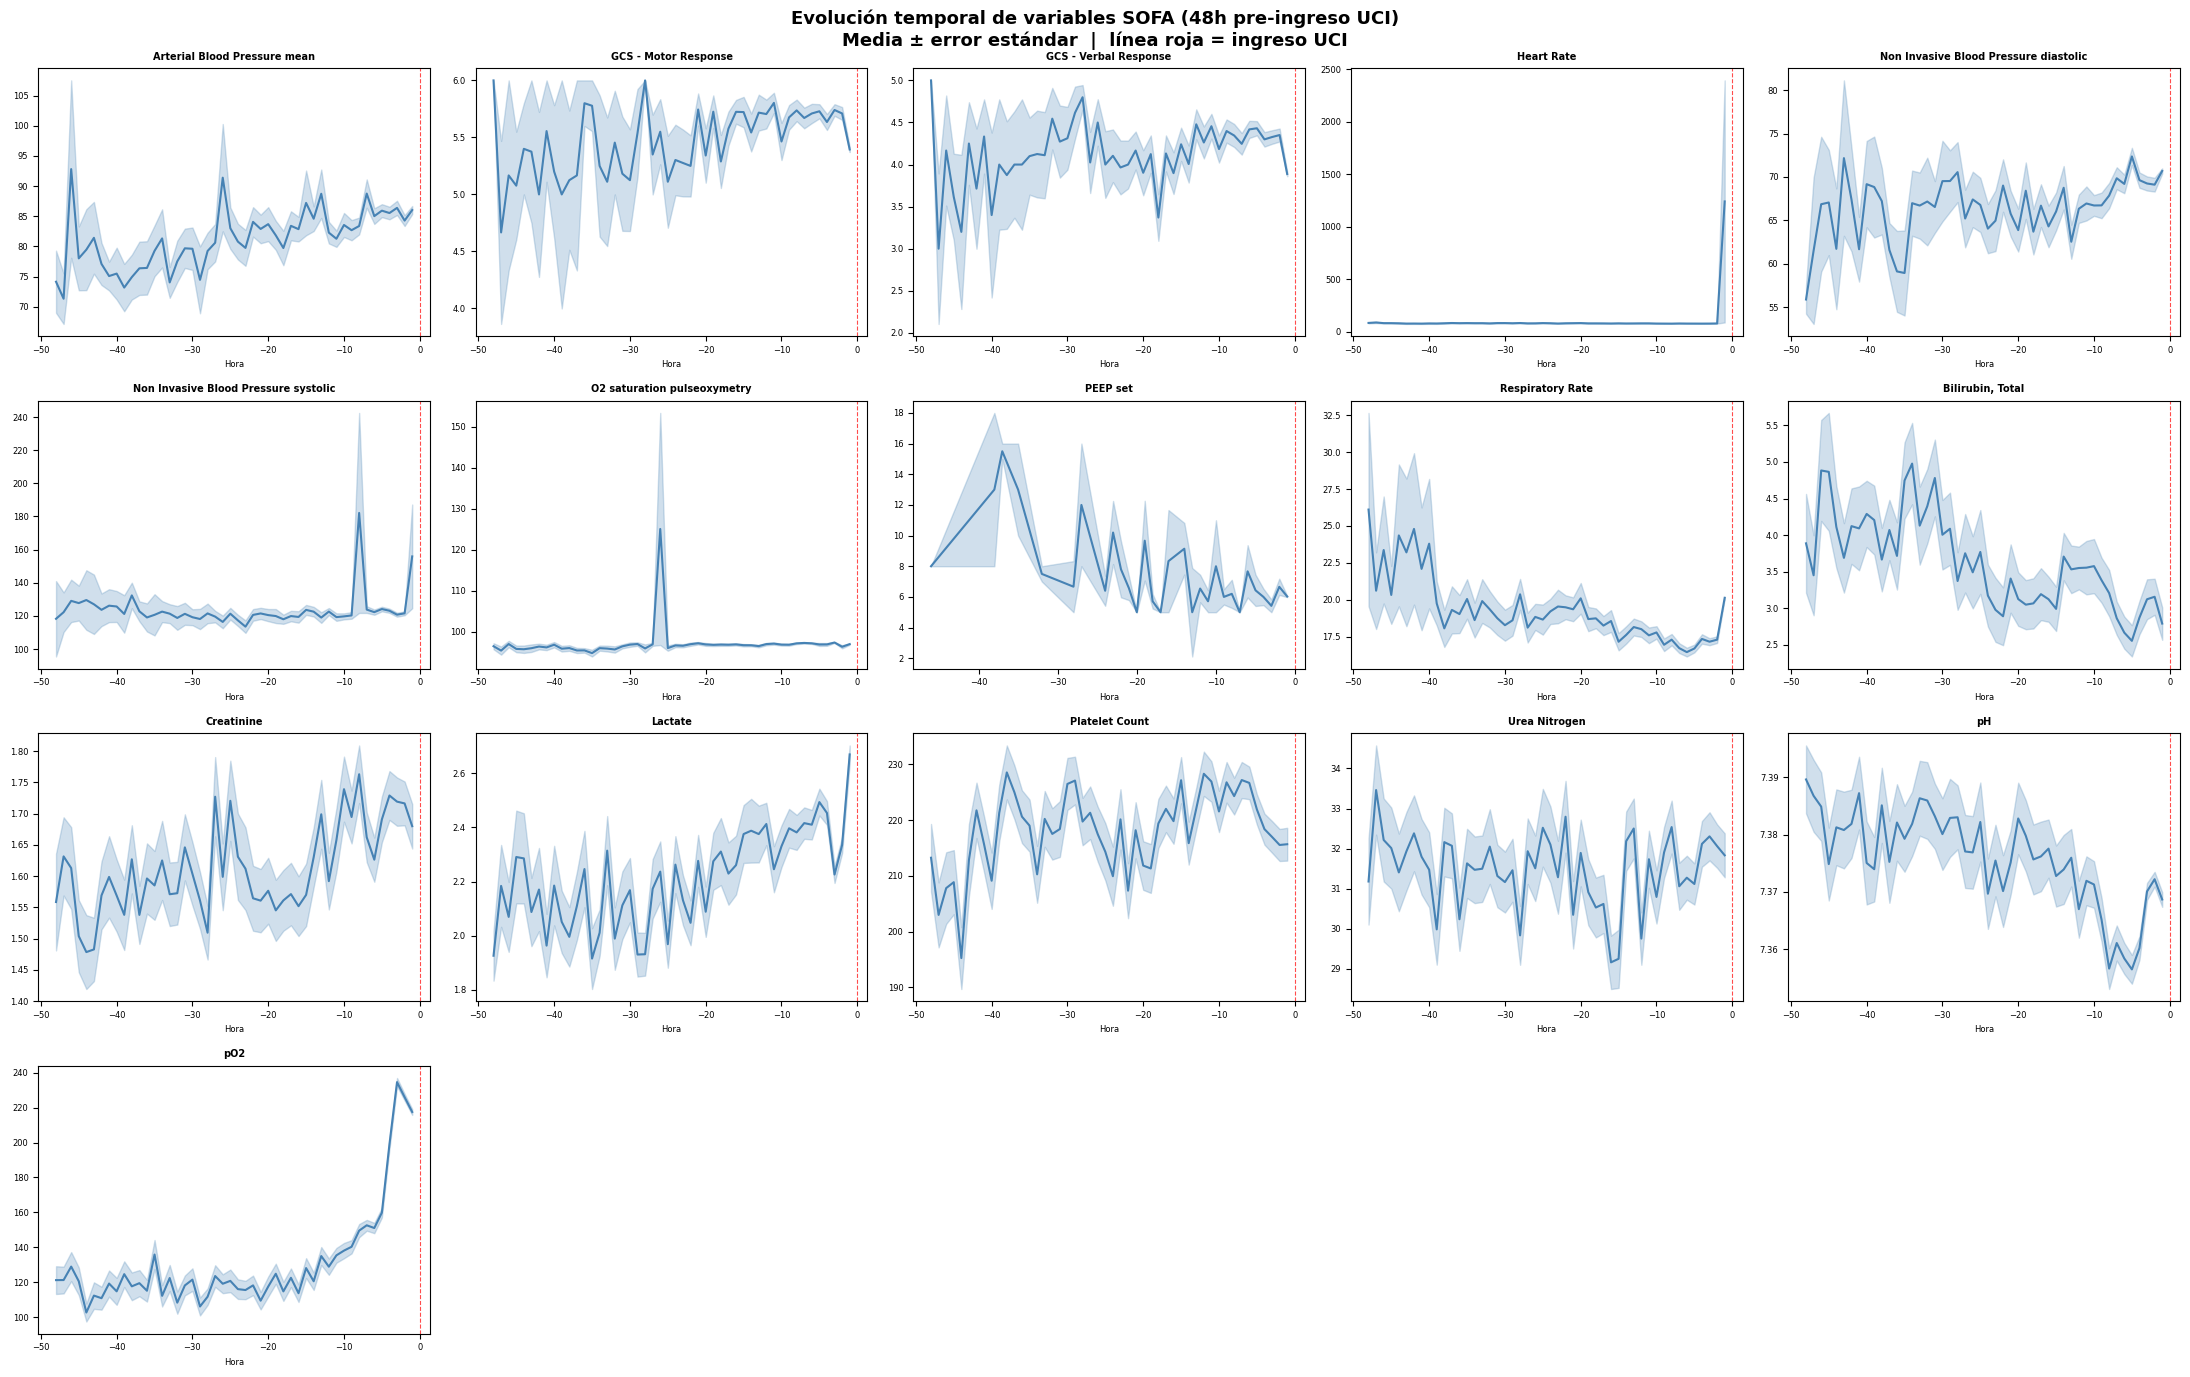

In [33]:
# === Tendencias temporales: media ± error estándar por variable ===
fig, axes = plt.subplots(4, 5, figsize=(22, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    trend = features_df.groupby('hour_bucket')[col].agg(['mean', 'sem']).dropna()
    if trend.empty:
        ax.set_visible(False)
        continue
    ax.plot(trend.index, trend['mean'], color='steelblue', linewidth=1.5)
    ax.fill_between(
        trend.index,
        trend['mean'] - trend['sem'],
        trend['mean'] + trend['sem'],
        alpha=0.25, color='steelblue'
    )
    ax.axvline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='Ingreso UCI')
    ax.set_title(col, fontsize=7, fontweight='bold')
    ax.set_xlabel('Hora', fontsize=6)
    ax.tick_params(labelsize=6)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Evolución temporal de variables SOFA (48h pre-ingreso UCI)\nMedia ± error estándar  |  línea roja = ingreso UCI',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

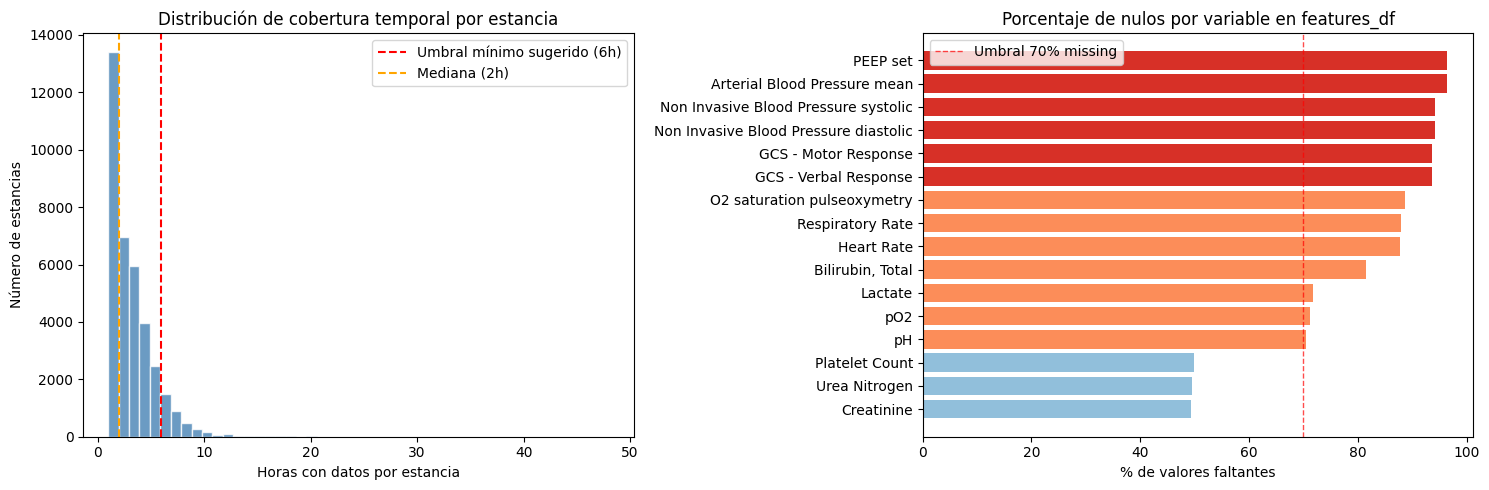


Estancias con >= 6h de datos: 3,661 (10.1%)
Estancias con < 6h de datos:  32,703 (89.9%)


In [34]:
# === Histograma de cobertura temporal por estancia + % nulos por variable ===
horas_por_estancia = features_df.groupby('stay_id')['hour_bucket'].count()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de horas con datos
ax1.hist(horas_por_estancia, bins=48, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(6, color='red', linestyle='--', linewidth=1.5, label='Umbral mínimo sugerido (6h)')
ax1.axvline(horas_por_estancia.median(), color='orange', linestyle='--', linewidth=1.5,
            label=f'Mediana ({horas_por_estancia.median():.0f}h)')
ax1.set_xlabel('Horas con datos por estancia')
ax1.set_ylabel('Número de estancias')
ax1.set_title('Distribución de cobertura temporal por estancia')
ax1.legend()

# % nulos por variable (barras horizontales)
null_pct_sorted = features_df[feature_cols].isna().mean().sort_values(ascending=True)
colors = ['#d73027' if v > 0.9 else '#fc8d59' if v > 0.7 else '#91bfdb' for v in null_pct_sorted]
ax2.barh(null_pct_sorted.index, null_pct_sorted.values * 100, color=colors)
ax2.axvline(70, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Umbral 70% missing')
ax2.set_xlabel('% de valores faltantes')
ax2.set_title('Porcentaje de nulos por variable en features_df')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nEstancias con >= 6h de datos: {(horas_por_estancia >= 6).sum():,} "
      f"({(horas_por_estancia >= 6).mean()*100:.1f}%)")
print(f"Estancias con < 6h de datos:  {(horas_por_estancia < 6).sum():,} "
      f"({(horas_por_estancia < 6).mean()*100:.1f}%)")

## Exportación

Guardado de la matriz de features final lista para el siguiente paso del pipeline (preprocesado e imputación).

In [35]:
features_df.columns.name = None

FEATURES_ALL_PATH = f'{OUTPUT_DIR}/features_all.parquet'
COHORT_ALL_PATH = f'{OUTPUT_DIR}/cohort_all.parquet'

features_df.to_parquet(FEATURES_ALL_PATH, index=False)
cohort_all.to_parquet(COHORT_ALL_PATH, index=False)

print(f'features_all → {FEATURES_ALL_PATH}')
print(f'cohort_all   → {COHORT_ALL_PATH}')
print(f'Shape features_all: {features_df.shape}')
print(f'Variables: {feature_cols}')
print(f'\nDistribución de labels:')
print(cohort_all['label'].value_counts().to_string())

features_all → ../data/processed/features_all.parquet
cohort_all   → ../data/processed/cohort_all.parquet
Shape features_all: (101981, 18)
Variables: ['Arterial Blood Pressure mean', 'GCS - Motor Response', 'GCS - Verbal Response', 'Heart Rate', 'Non Invasive Blood Pressure diastolic', 'Non Invasive Blood Pressure systolic', 'O2 saturation pulseoxymetry', 'PEEP set', 'Respiratory Rate', 'Bilirubin, Total', 'Creatinine', 'Lactate', 'Platelet Count', 'Urea Nitrogen', 'pH', 'pO2']

Distribución de labels:
label
1    29966
0    29966
